In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns


In [12]:
df = pd.read_csv('Data_sorted.csv')

# timestamp -> datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# 1. นับจำนวนบรรทัดทั้งหมด
total_rows = len(df)
print(f"จำนวนบรรทัดทั้งหมด: {total_rows} บรรทัด\n")

# intervalกับแถวก่อนหน้า
df['delta'] = df['timestamp'].diff()
df['delta_sec'] = df['delta'].dt.total_seconds()

# จำนวนบรรทัดตามระยะห่างเวลา
interval_counts = df['delta_sec'].value_counts()

print("แยกตามระยะห่างเวลา")
for sec, count in interval_counts.items():
    if pd.notna(sec): # ข้ามบรรทัดแรกที่เป็น NaN (เพราะไม่มีแถวก่อนหน้าให้ลบ)
        print(f" {sec:.0f} วินาที {int(count):,} บรรทัด")

จำนวนบรรทัดทั้งหมด: 86016 บรรทัด

แยกตามระยะห่างเวลา
 1 วินาที 52,583 บรรทัด
 5 วินาที 32,322 บรรทัด
 6 วินาที 500 บรรทัด
 4 วินาที 443 บรรทัด
 7 วินาที 9 บรรทัด
 45 วินาที 6 บรรทัด
 125 วินาที 5 บรรทัด
 130 วินาที 3 บรรทัด
 120 วินาที 3 บรรทัด
 845 วินาที 2 บรรทัด
 445 วินาที 2 บรรทัด
 2 วินาที 2 บรรทัด
 110 วินาที 2 บรรทัด
 475 วินาที 2 บรรทัด
 5895 วินาที 1 บรรทัด
 3640 วินาที 1 บรรทัด
 1005 วินาที 1 บรรทัด
 3885 วินาที 1 บรรทัด
 5191 วินาที 1 บรรทัด
 3575 วินาที 1 บรรทัด
 1788321 วินาที 1 บรรทัด
 1160 วินาที 1 บรรทัด
 4897 วินาที 1 บรรทัด
 405 วินาที 1 บรรทัด
 2845 วินาที 1 บรรทัด
 465 วินาที 1 บรรทัด
 2139 วินาที 1 บรรทัด
 320 วินาที 1 บรรทัด
 205 วินาที 1 บรรทัด
 2280 วินาที 1 บรรทัด
 2486 วินาที 1 บรรทัด
 127 วินาที 1 บรรทัด
 572 วินาที 1 บรรทัด
 302 วินาที 1 บรรทัด
 135 วินาที 1 บรรทัด
 531 วินาที 1 บรรทัด
 6056 วินาที 1 บรรทัด
 18388 วินาที 1 บรรทัด
 6905 วินาที 1 บรรทัด
 1720 วินาที 1 บรรทัด
 861 วินาที 1 บรรทัด
 1941 วินาที 1 บรรทัด
 75 วินาที 1 บรรทัด
 1345 วินาที 1 บรรทัด


In [16]:
df = pd.read_csv('Data_sorted.csv')

# timestamp เป็น datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# 1. นับจำนวนบรรทัดทั้งหมด
total_rows = len(df)
print(f"มีทั้งหมด {total_rows:,} บรรทัด\n")

# interval กับแถวก่อนหน้า
df['delta'] = df['timestamp'].diff()
df['delta_sec'] = df['delta'].dt.total_seconds()

# 4อันดับที่บ่อยสุด
interval_counts = df['delta_sec'].value_counts()
top = interval_counts.head(4)

print("แยกตามระยะห่างเวลา (ความถี่หลัก)")
for sec, count in top.items():
    pct = count / (total_rows - 1) * 100
    print(f" {sec:.0f} วินาที {int(count):,} บรรทัด  ({pct:.2f}%)")

มีทั้งหมด 86,016 บรรทัด

แยกตามระยะห่างเวลา (ความถี่หลัก)
 1 วินาที 52,583 บรรทัด  (61.13%)
 5 วินาที 32,322 บรรทัด  (37.58%)
 6 วินาที 500 บรรทัด  (0.58%)
 4 วินาที 443 บรรทัด  (0.52%)


In [17]:
df = pd.read_csv('Data_sorted.csv')

# 1. นับจำนวน anomaly
total_rows  = len(df)
anom_rows   = (df['anomaly'] == 1).sum()
nominal_rows= (df['anomaly'] == 0).sum()
anom_pct    = anom_rows / total_rows * 100

print(f"  Nominal : {nominal_rows:>7,} แถว ({nominal_rows/total_rows*100:5.2f}%)")
print(f"  Anomaly : {anom_rows:>7,} แถว ({anom_pct:5.2f}%)")

  Nominal :  59,781 แถว (69.50%)
  Anomaly :  26,235 แถว (30.50%)


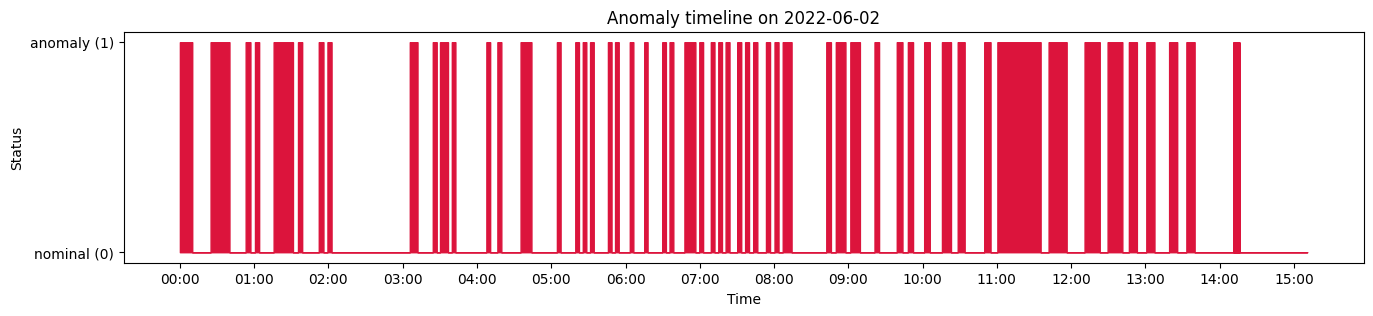

In [3]:
df = pd.read_csv('Data_sorted.csv', parse_dates=['timestamp'])
day = df[df['timestamp'].dt.date == pd.to_datetime('2022-06-02').date()]

fig, ax = plt.subplots(figsize=(16, 3))
ax.fill_between(day['timestamp'], 0, day['anomaly'], step='post', color='crimson')
ax.set_yticks([0, 1])
ax.set_yticklabels(['nominal (0)', 'anomaly (1)'])
ax.xaxis.set_major_locator(mdates.HourLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_xlabel('Time')
ax.set_ylabel('Status')
ax.set_title('Anomaly timeline on 2022-06-02')
plt.show()

In [ ]:

df = pd.read_csv('Data_sorted.csv', parse_dates=['timestamp'])
df['date'] = df['timestamp'].dt.date

print(f"วันแรก: {df['date'].min()}")
print(f"วันสุดท้าย: {df['date'].max()}")
print(f"ช่วงเวลาของDataset: {(df['date'].max() - df['date'].min()).days + 1} วัน")
print(f"มีข้อมูลจริง: {df['date'].nunique()} วัน\n")

print(f"{'วันที่':<12} {'จำนวนแถว':>8}   {'ระยะเวลา':>10}")
for d, g in df.groupby('date'):
    sec = (g['timestamp'].max() - g['timestamp'].min()).total_seconds()
    h, m = divmod(int(sec // 60), 60)
    print(f"{str(d):<12} {len(g):>8,}   {h}:{m:02d}".rjust(10))

วันแรก: 2022-01-04
วันสุดท้าย: 2022-06-02
ช่วงเวลาของDataset: 150 วัน
มีข้อมูลจริง: 14 วัน

วันที่       จำนวนแถว     ระยะเวลา
2022-01-04      2,222   3:05
2022-01-05      1,077   6:33
2022-01-26      5,014   23:47
2022-01-27      8,418   23:50
2022-01-28      5,157   22:50
2022-01-29      5,270   15:17
2022-02-05      1,927   11:12
2022-02-06      1,702   20:09
2022-02-08      1,039   1:26
2022-02-09        405   0:33
2022-02-10        307   0:25
2022-02-11        243   0:20
2022-06-01      1,231   0:20
2022-06-02     52,004   15:10


In [28]:
df = pd.read_csv('Data_sorted.csv', parse_dates=['timestamp'])
gaps = df['timestamp'].diff().dt.total_seconds().dropna()

bins = [0, 10, 60, 600, 3600, 86400, float('inf')]
labels = ['≤10 วิ', '11-60 วิ', '1-10 นาที', '10นาที-1ชม.', '1-24 ชม.', '>1 วัน']
counts = pd.cut(gaps, bins=bins, labels=labels).value_counts().reindex(labels)

print(f"{'ช่วง gap':<15} {'จำนวนครั้ง':>12}")
print("─" * 28)
for label, count in counts.items():
    print(f"{label:<15} {count:>12,}")

ช่วง gap          จำนวนครั้ง
────────────────────────────
≤10 วิ                85,861
11-60 วิ                  10
1-10 นาที                 53
10นาที-1ชม.               63
1-24 ชม.                  23
>1 วัน                     5


In [29]:
df = pd.read_csv('Data_sorted.csv', parse_dates=['timestamp'])

df['run'] = (df['anomaly'].diff() != 0).cumsum()
bursts = df[df['anomaly']==1].groupby('run')['timestamp'].agg(['min','max'])
dur = (bursts['max'] - bursts['min']).dt.total_seconds()

print(f"Min:    {dur.min():.0f} วินาที")
print(f"Median: {dur.median()/60:.1f} นาที")
print(f"Mode:   {dur.mode().iloc[0]:.0f} วินาที")
print(f"Max:    {dur.max()/3600:.2f} ชั่วโมง")
print(f"Burst ที่ยาวเกิน 1 ชม.: {(dur > 3600).sum()} ครั้ง จากทั้งหมด {len(dur)} ครั้ง")

Min:    0 วินาที
Median: 3.1 นาที
Mode:   3 วินาที
Max:    12.23 ชั่วโมง
Burst ที่ยาวเกิน 1 ชม.: 6 ครั้ง จากทั้งหมด 164 ครั้ง


IQR คือ inter quartile range เกิดจาก P75 - P25 เพื่อ represent 50% ของ data

In [42]:
import pandas as pd

df = pd.read_csv('Data_sorted.csv', parse_dates=['timestamp'])
df['run'] = (df['anomaly'].diff() != 0).cumsum()
dur = df[df['anomaly']==1].groupby('run')['timestamp'].agg(lambda x: (x.max()-x.min()).total_seconds())

q = dur.quantile([0.25, 0.5, 0.75, 0.9]) / 60
print(f"Mean: {dur.mean()/60:.2f} นาที")
print(f"P25:  {q[0.25]:.1f} นาที")
print(f"P50:  {q[0.50]:.1f} นาที")
print(f"P75:  {q[0.75]:.1f} นาที")
print(f"P90:  {q[0.90]:.1f} นาที")
print(f"IQR:  {q[0.75]-q[0.25]:.1f} นาที")

Mean: 12.23 นาที
P25:  0.1 นาที
P50:  3.1 นาที
P75:  5.6 นาที
P90:  13.9 นาที
IQR:  5.6 นาที


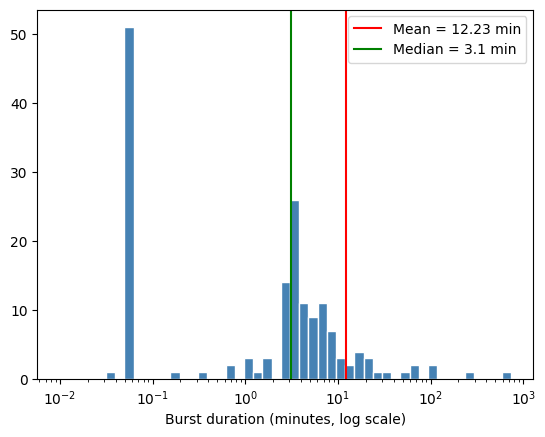

In [44]:
df = pd.read_csv('Data_sorted.csv', parse_dates=['timestamp'])
df['run'] = (df['anomaly'].diff() != 0).cumsum()
dur = df[df['anomaly']==1].groupby('run')['timestamp'].agg(lambda x: (x.max()-x.min()).total_seconds()) / 60

plt.hist(dur[dur > 0], bins=np.logspace(np.log10(0.01), np.log10(dur.max()), 50), color='steelblue', edgecolor='white')
plt.axvline(dur.mean(),   color='red',   label=f'Mean = {dur.mean():.2f} min')
plt.axvline(dur.median(), color='green', label=f'Median = {dur.median():.1f} min')
plt.xscale('log')
plt.xlabel('Burst duration (minutes, log scale)')
plt.legend()
plt.show()

วันที่มีanomalyเยอะที่สุดเรียงจากน้อยไปมาก(Total per day anomaly)

In [47]:
df = pd.read_csv('Data_sorted.csv', parse_dates=['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)
df['date'] = df['timestamp'].dt.date

# คำนวณ interval จากแถวนี้ ไปแถวถัดไป (ภายในวันเดียวกัน)
df['interval'] = df.groupby('date')['timestamp'].diff().shift(-1).dt.total_seconds()

# กรณี dropout (>60s) หรือแถวสุดท้ายของวัน → ใช้ median cadence ของวันนั้นแทน
day_cadence = df.groupby('date')['interval'].median()
df['interval'] = df['interval'].fillna(df['date'].map(day_cadence))
df.loc[df['interval'] > 60, 'interval'] = df['date'].map(day_cadence)

per_day = df[df['anomaly']==1].groupby('date')['interval'].sum().sort_values(ascending=False) / 3600
for d, h in per_day.items():
    print(f"{d}  {h:.2f} ชม.")

2022-06-02  5.39 ชม.
2022-01-26  2.28 ชม.
2022-01-27  1.40 ชม.
2022-02-05  1.33 ชม.
2022-01-28  0.93 ชม.
2022-02-06  0.83 ชม.
2022-01-29  0.54 ชม.
2022-06-01  0.32 ชม.
2022-02-09  0.28 ชม.
2022-01-05  0.15 ชม.
2022-02-11  0.15 ชม.
2022-02-10  0.09 ชม.


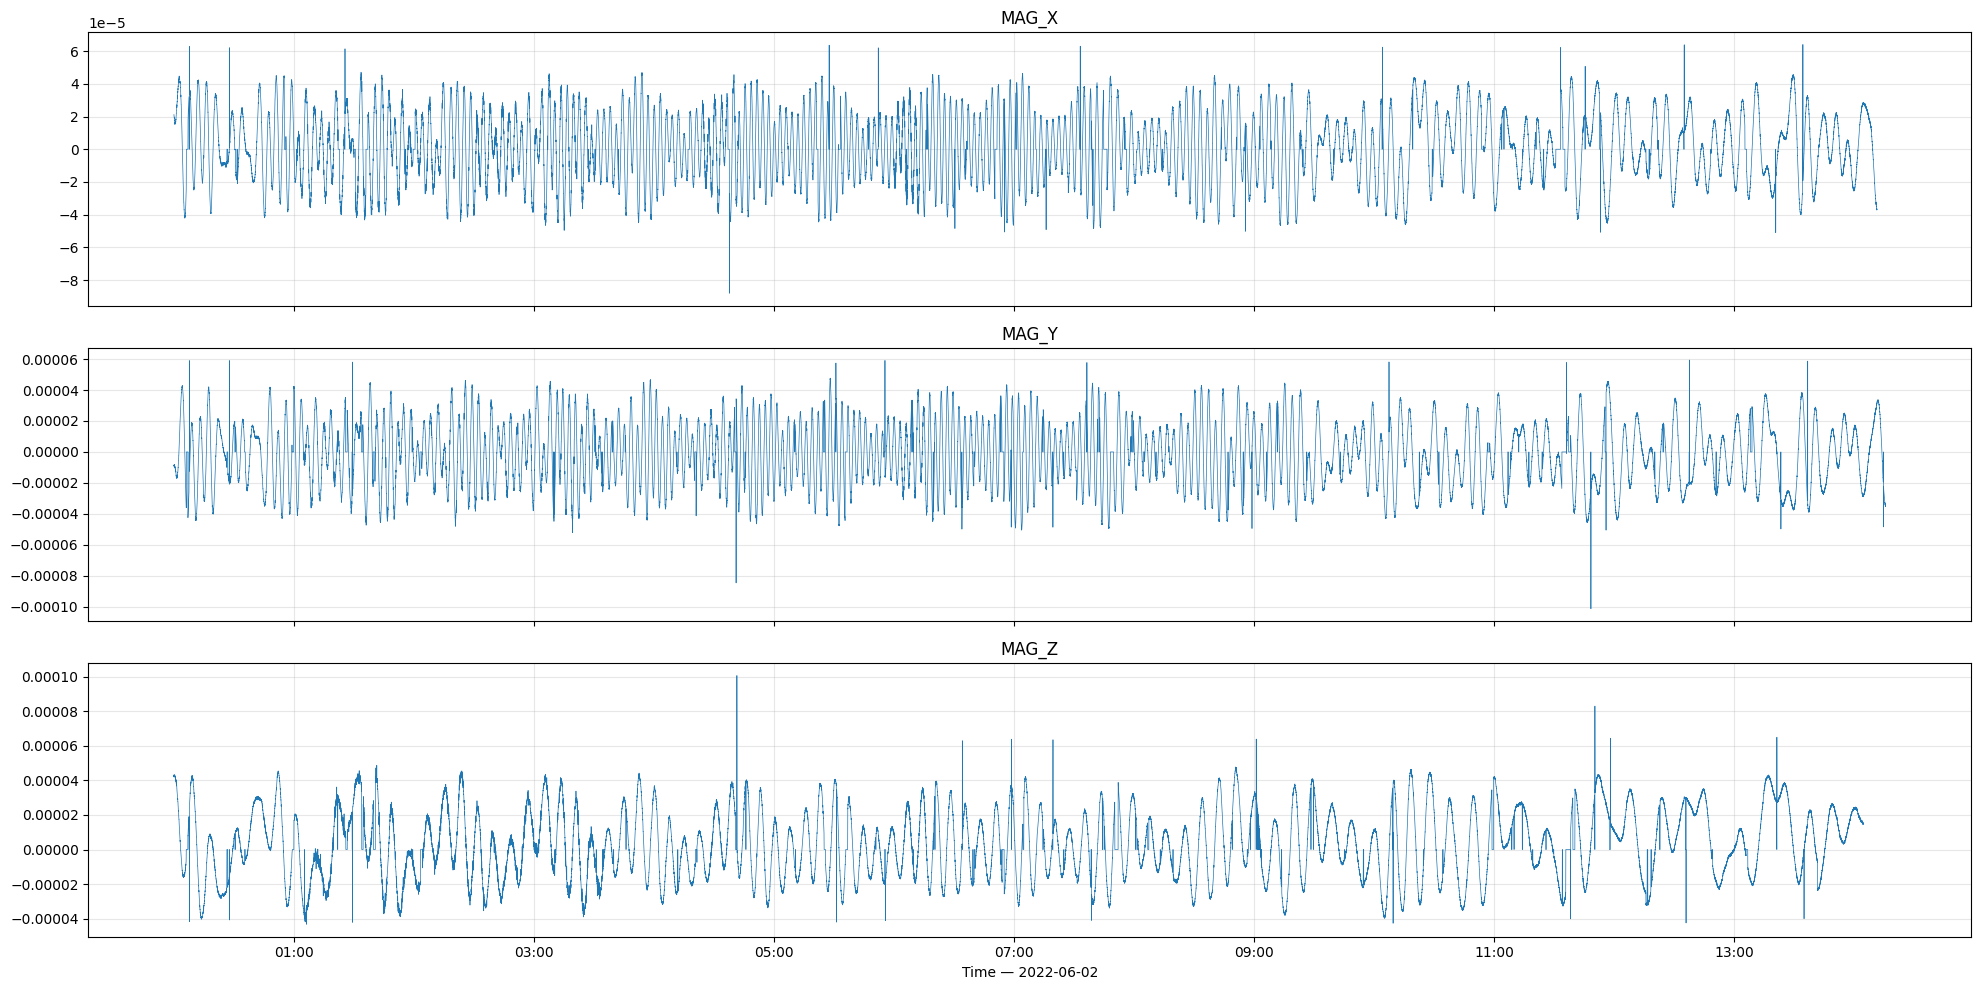

In [24]:
df = pd.read_csv('Data_sorted_renamed.csv', parse_dates=['timestamp'])
day = df[df['timestamp'].dt.date == pd.to_datetime('2022-06-02').date()]
sensors = ['MAG_X','MAG_Y','MAG_Z']

fig, axes = plt.subplots(3, 1, figsize=(20, 10), sharex=True)
for ax, s in zip(axes, sensors):
    valid = day[['timestamp', s]].dropna()
    ax.plot(valid['timestamp'], valid[s], linewidth=0.5)
    ax.set_title(s)
    ax.grid(alpha=0.3)

axes[-1].xaxis.set_major_locator(mdates.HourLocator(interval=2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axes[-1].set_xlabel('Time — 2022-06-02')
plt.tight_layout()
plt.show()

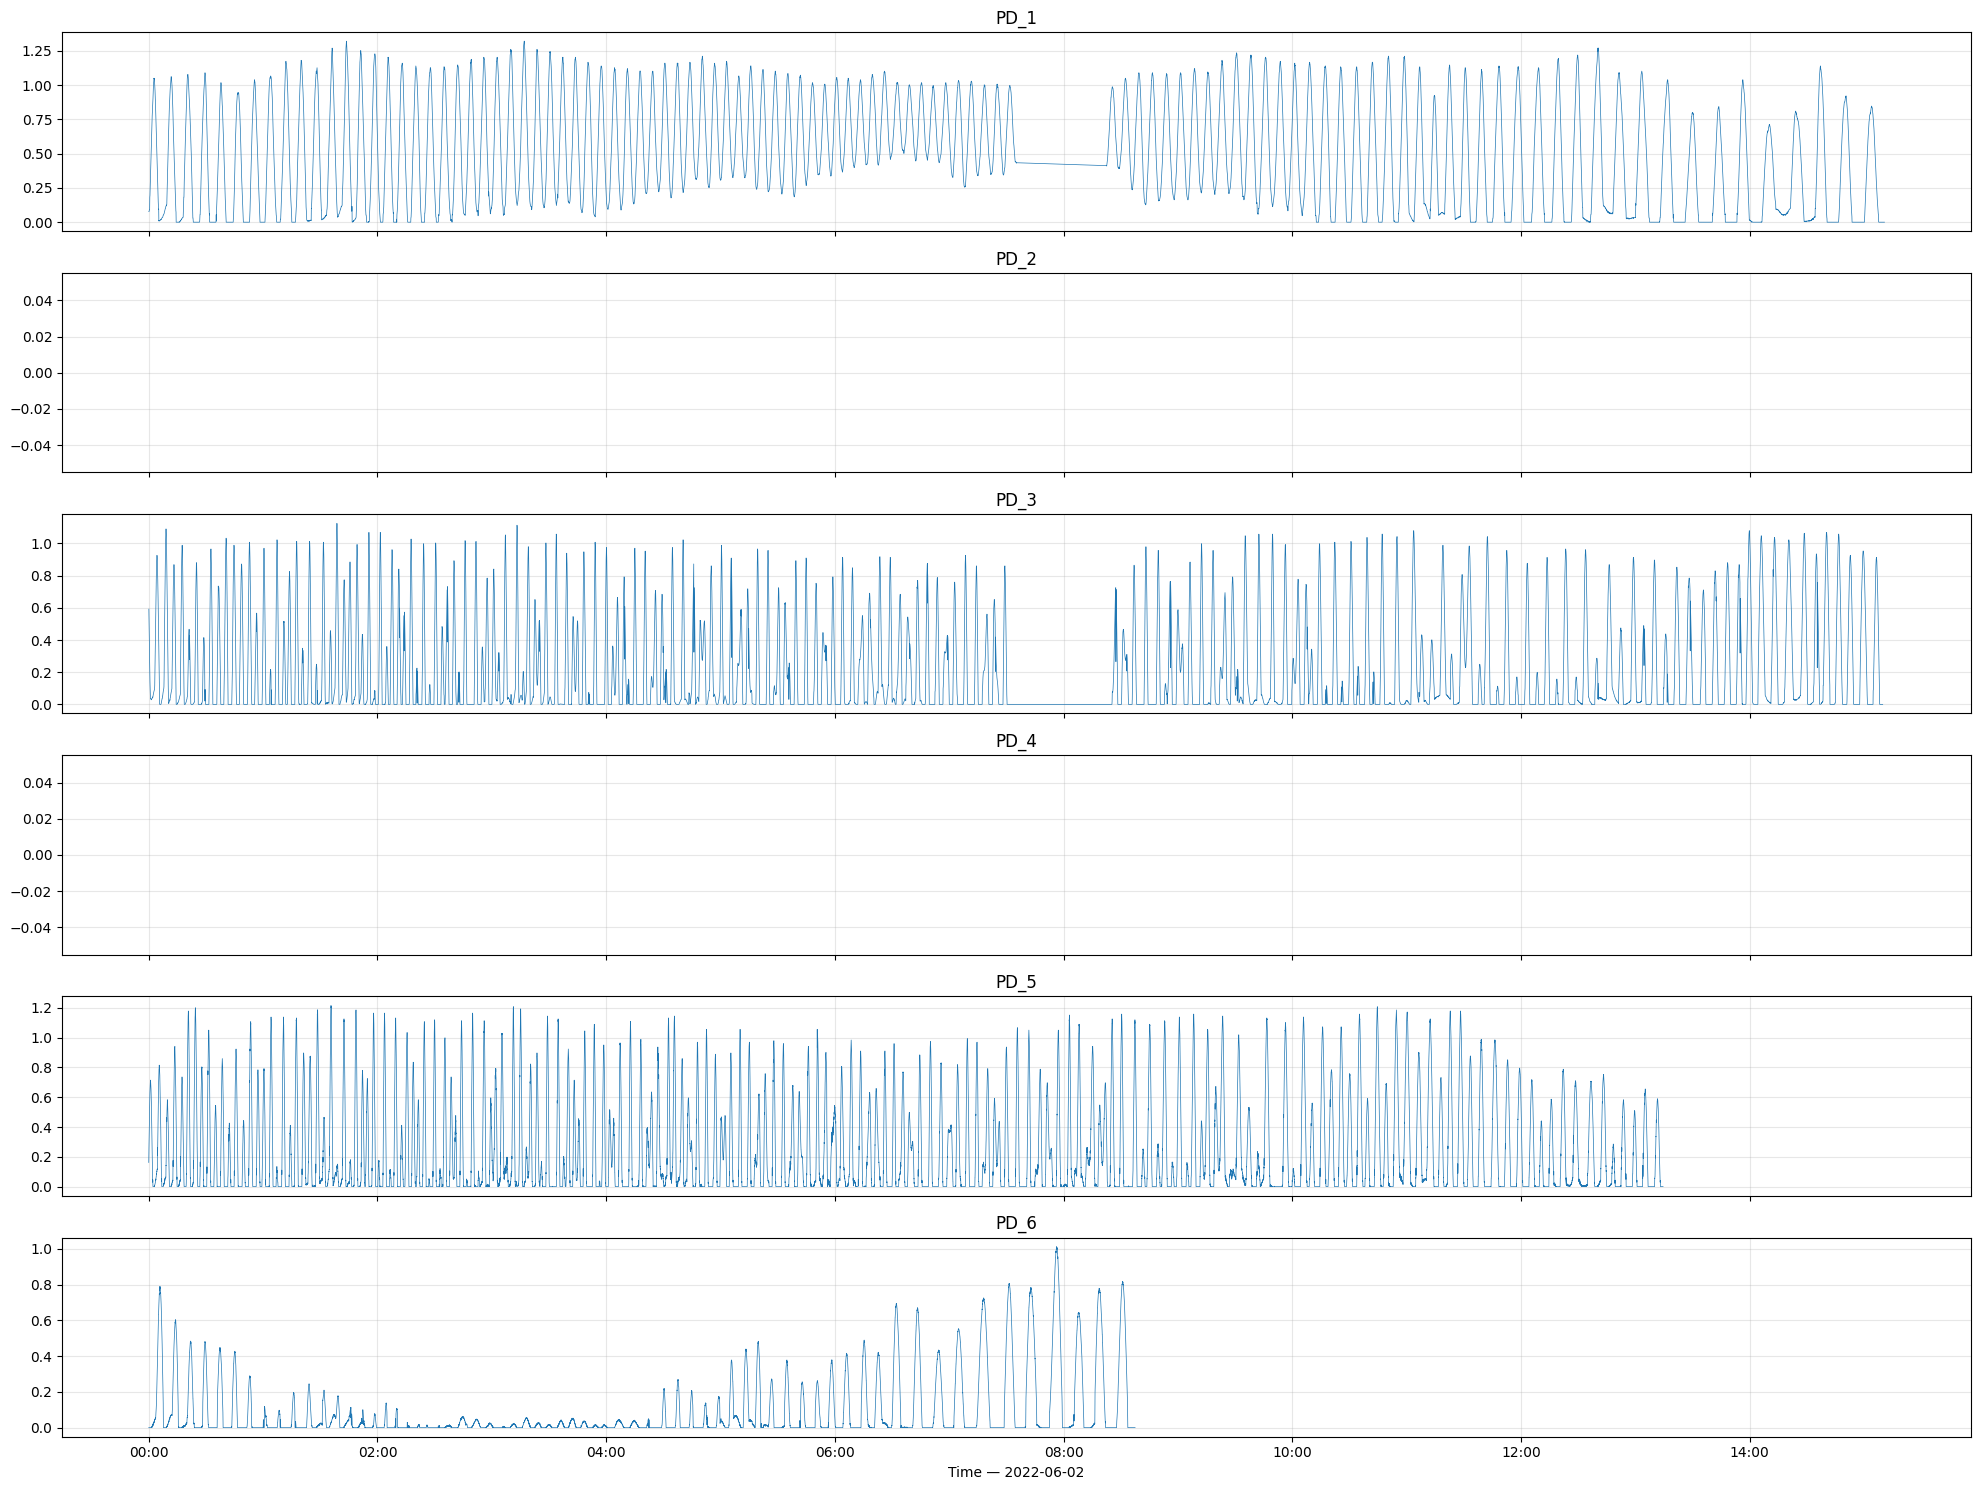

In [25]:
sensors = ['PD_1','PD_2','PD_3','PD_4','PD_5','PD_6']

fig, axes = plt.subplots(6, 1, figsize=(20, 15), sharex=True)
for ax, s in zip(axes, sensors):
    valid = day[['timestamp', s]].dropna()
    ax.plot(valid['timestamp'], valid[s], linewidth=0.5)
    ax.set_title(s)
    ax.grid(alpha=0.3)

axes[-1].xaxis.set_major_locator(mdates.HourLocator(interval=2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axes[-1].set_xlabel('Time — 2022-06-02')
plt.tight_layout()
plt.show()

In [5]:
df = pd.read_csv('Data_sorted_renamed.csv', parse_dates=['timestamp'])
day = df[df['timestamp'].dt.date == pd.to_datetime('2022-06-02').date()]

print(day[['MAG_X','MAG_Y','MAG_Z','PD_1','PD_2','PD_3','PD_4','PD_5','PD_6']].notna().sum().to_string())

MAG_X    51084
MAG_Y    51344
MAG_Z    50674
PD_1     10361
PD_2         0
PD_3     10146
PD_4         0
PD_5     47673
PD_6     31052


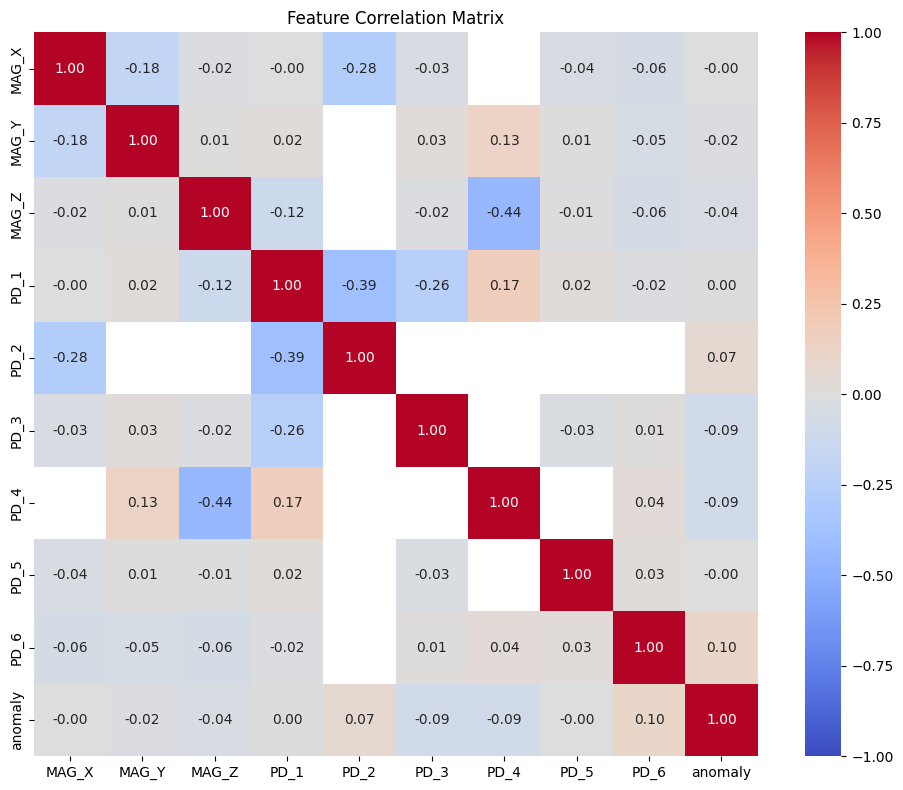

In [9]:
df = pd.read_csv('Data_sorted_renamed.csv')
features = ['MAG_X','MAG_Y','MAG_Z','PD_1','PD_2','PD_3','PD_4','PD_5','PD_6','anomaly']
corr = df[features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()